# AQI Forecasting — Feature Engineering & Model Experiments

A learning-oriented, production-shaped notebook for forecasting AQI N days ahead
from pollutant + weather history. Every section explains **what** it does, **why**
it's structured that way, and **how** the code works — written so someone opening
this repo cold (including future-you) can follow it without side context.

**Design principles used throughout:**
- **Modular over hardcoded.** Nearly everything is a function that takes the
  forecast horizon, the split strategy, or the model as a parameter, instead of a
  notebook that only works for `aqi_next_1d` and breaks the moment you change it.
- **Every model goes through the same evaluation path.** One `evaluate_and_log()`
  and one `plot_model_diagnostics()` function are reused for every model, so
  results are directly comparable and you only have to learn to read one set of
  plots.
- **Delta-target throughout.** Every model predicts *change* in AQI
  (`aqi_next_Nd - european_aqi`), not the raw level — explained in Section 9.

1. Setup
2. API Client Layer — pass a city name, coordinates are resolved automatically
3. Data Validation Layer
4. Feature Engineering Layer
5. Quick Smoke Test
6. Historical Data Pipeline
7. Exploratory Data Analysis
8. Outlier Assessment & Handling
9. Target & Split Utilities — the modular horizon/split machinery
10. Model Training & Diagnostics Framework — one function, every model
11. Baseline Models: Random Forest & Ridge
12. XGBoost
13. Hyperparameter Tuning — GridSearchCV & RandomizedSearchCV
14. Walk-Forward Validation
15. Deep Learning: Feed-Forward NN & LSTM
16. Multi-Horizon Comparison (1-day / 2-day / 3-day ahead)
17. Model Leaderboard
18. Next Steps


# 03 — Model Experiments & Leaderboard

Model training (Ridge, Random Forest, XGBoost, Neural Nets), Hyperparameter tuning, and Model Leaderboard.


## 1. Setup

In [ ]:
!pip install openmeteo_requests requests_cache retry_requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.9/809.9 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 111.1 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
# --- stdlib ---
from abc import ABC, abstractmethod
from datetime import datetime
from typing import Any, Dict, List, Optional

# --- data & viz ---
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- API client ---
import openmeteo_requests
import requests_cache
from retry_requests import retry
from requests.exceptions import HTTPError

# --- validation ---
from pydantic import BaseModel, Field, field_validator, ValidationError

# --- sklearn ---
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error,
)

# --- xgboost ---
import xgboost as xgb

# --- deep learning ---
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style="whitegrid")

# A running scoreboard. Every call to evaluate_and_log() (Section 10) appends one
# row here — this IS the notebook's source of truth for "which model won," so it
# gets reset at the top of every fresh run instead of silently accumulating rows
# across kernel sessions (that's an easy way to end up reporting stale numbers).
leaderboard = []

## 2. API Client Layer

**What this does:** wraps Open-Meteo's two APIs (air quality + historical weather)
behind one interface, and resolves a **city name** to coordinates internally so the
rest of the notebook never has to know or care about lat/lon.

**Why a city dictionary instead of a geocoding API call:** an extra network request
per city lookup is pure overhead for a fixed, known set of cities you're actually
going to use. A dictionary is one lookup, zero latency, zero failure mode. Add a
city once (`CITY_COORDINATES["your_city"] = (lat, lon)`) and every function below
picks it up automatically.

**Why an abstract base class for a single client:** `OpenMeteoClient` isn't the
only air-quality provider that will ever exist. Coding against `BaseAPIClient`
instead of `OpenMeteoClient` directly means adding a second provider later (a paid
fallback, a different region's better-covered source) is one new subclass, not a
rewrite of every place that calls `client.fetch_historical(...)`. This is the
**Strategy pattern**: the caller depends on the interface, not the implementation.

In [ ]:
# Known cities — add more as needed. Keys are lowercased for lookup;
# CITY_COORDINATES["lahore"] and CITY_COORDINATES["Lahore"] both resolve.
CITY_COORDINATES: Dict[str, tuple] = {
    "lahore": (31.558, 74.351),
    "karachi": (24.8607, 67.0011),
    "islamabad": (33.6844, 73.0479),
    "delhi": (28.6139, 77.2090),
    "beijing": (39.9042, 116.4074),
    "new york": (40.7128, -74.0060),
    "london": (51.5074, -0.1278),
    "los angeles": (34.0522, -118.2437),
}

def resolve_city(city: str) -> tuple:
    """Look up (lat, lon) for a known city name. Raises a clear error for an
    unknown one instead of silently failing deep inside an API call."""
    key = city.strip().lower()
    if key not in CITY_COORDINATES:
        known = ", ".join(sorted(CITY_COORDINATES))
        raise ValueError(f"Unknown city '{city}'. Known cities: {known}. "
                          f"Add it to CITY_COORDINATES to use it.")
    return CITY_COORDINATES[key]

In [ ]:
AQI_VARIABLES = [
    "pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide",
    "sulphur_dioxide", "ozone", "uv_index", "aerosol_optical_depth", "european_aqi",
]

WEATHER_VARIABLES = [
    "temperature_2m", "wind_direction_10m", "wind_speed_10m", "rain",
    "weather_code", "wind_gusts_10m", "cloud_cover", "relative_humidity_2m",
]


class BaseAPIClient(ABC):
    """Abstract base for all API clients — every provider implements the same
    four methods, so the rest of the notebook only ever talks to this interface."""

    def __init__(self, api_key: str = None):
        self.api_key = api_key

    @abstractmethod
    def fetch_current(self, city: str) -> Dict[str, Any]:
        pass

    @abstractmethod
    def fetch_historical(self, city: str, start_date: str, end_date: str) -> list:
        pass

    @abstractmethod
    def fetch_current_weather(self, city: str) -> Dict[str, Any]:
        pass

    @abstractmethod
    def fetch_historical_weather(self, city: str, start_date: str, end_date: str) -> list:
        pass


class OpenMeteoClient(BaseAPIClient):
    """Open-Meteo air-quality + weather client. No API key needed."""

    AQI_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
    WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
    WEATHER_HISTORY_URL = "https://archive-api.open-meteo.com/v1/archive"

    def __init__(self):
        super().__init__()
        cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
        retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
        self.client = openmeteo_requests.Client(session=retry_session)

    # ---- shared internals --------------------------------------------------

    def _fetch_current(self, url: str, variables: List[str], city: str,
                        lat: float, lon: float) -> Dict[str, Any]:
        params = {"latitude": lat, "longitude": lon, "current": variables, "timezone": "auto"}
        print(f"Fetching current data from {url} for {city} ({lat}, {lon})")
        try:
            response = self.client.weather_api(url, params=params)[0]
            current = response.Current()
            data = {
                "date": pd.to_datetime(current.Time(), unit="s", utc=True)
                    .tz_convert(response.Timezone().decode()).tz_localize(None),
                "city": city, "lat": lat, "lon": lon,
            }
            data.update({var: round(current.Variables(i).Value(), 5) for i, var in enumerate(variables)})
            return data
        except Exception as e:
            print(f"Request failed: {e}")
            raise HTTPError(f"OpenMeteo current request failed ({url}): {e}")

    def _fetch_historical(self, url: str, variables: List[str], city: str,
                           lat: float, lon: float, start_date: str, end_date: str) -> list:
        params = {
            "latitude": lat, "longitude": lon, "hourly": variables,
            "timezone": "auto", "start_date": start_date, "end_date": end_date,
        }
        print(f"Fetching historical data from {url} for {city} [{start_date} -> {end_date}]")
        try:
            response = self.client.weather_api(url, params=params)[0]
            hourly = response.Hourly()
            hourly_data = {
                "date": pd.date_range(
                    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
                    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
                    freq=pd.Timedelta(seconds=hourly.Interval()),
                    inclusive="left",
                ).tz_convert(response.Timezone().decode()),
                "city": city, "lat": lat, "lon": lon,
            }
            for i, var in enumerate(variables):
                hourly_data[var] = hourly.Variables(i).ValuesAsNumpy()
            return pd.DataFrame(hourly_data).to_dict(orient="records")
        except Exception as e:
            print(f"Request failed: {e}")
            raise HTTPError(f"OpenMeteo historical request failed ({url}): {e}")

    # ---- public API — all take a city NAME, coordinates resolved internally ---

    def fetch_current(self, city: str) -> Dict[str, Any]:
        lat, lon = resolve_city(city)
        return self._fetch_current(self.AQI_URL, AQI_VARIABLES, city, lat, lon)

    def fetch_historical(self, city: str, start_date: str, end_date: str) -> list:
        lat, lon = resolve_city(city)
        return self._fetch_historical(self.AQI_URL, AQI_VARIABLES, city, lat, lon, start_date, end_date)

    def fetch_current_weather(self, city: str) -> Dict[str, Any]:
        lat, lon = resolve_city(city)
        return self._fetch_current(self.WEATHER_URL, WEATHER_VARIABLES, city, lat, lon)

    def fetch_historical_weather(self, city: str, start_date: str, end_date: str) -> list:
        lat, lon = resolve_city(city)
        return self._fetch_historical(self.WEATHER_HISTORY_URL, WEATHER_VARIABLES, city, lat, lon, start_date, end_date)


class APIClientFactory:
    """Factory for the active client — swap providers here without touching
    anything that calls client.fetch_historical(...) elsewhere in the notebook."""

    @staticmethod
    def get_primary_client() -> BaseAPIClient:
        return OpenMeteoClient()

In [ ]:
client = APIClientFactory.get_primary_client()
CITY = "Lahore"   # change this one line to point the whole notebook at another city

## 4. Feature Engineering Layer

**What this does:** turns raw hourly readings into the feature set every model
below trains on — temporal encodings, pollutant ratios, lags, and rolling stats —
and builds the target column(s).

**Why `forecast_horizon` is a parameter, not a fixed column name:** we need "predict tomorrow" to "predict the next 3 days." Instead of
copy-pasting the feature engineering code once per horizon (and hand-editing three
near-identical copies every time something changes), `forecast_horizon=3` builds
`aqi_next_1d`, `aqi_next_2d`, and `aqi_next_3d` in one pass. Section 9 then picks
*one* of those columns as the active target — see the leakage note there for why
the others must be dropped from the feature set, not just ignored.

**A few specific choices worth understanding, not just copying:**
- **Cyclical (sin/cos) encoding for hour/day/month.** A model reading raw `hour=23`
  has no way to know it's adjacent to `hour=0` — to a linear model, 23 looks 23x
  "bigger" than 1. Mapping each cycle onto a circle (`sin`, `cos`) makes "close in
  time" mean "close in value" again.
- **`no2_o3_ratio` is clipped, not epsilon-divided.** `ozone` hits exactly 0 on
  hundreds of rows (mostly overnight). Dividing by `ozone + 1e-6` turns those rows
  into values in the hundreds of millions — a feature meant to range roughly 0-5
  spikes eight orders of magnitude past that, and standardizing it later doesn't
  fix the underlying distortion. Clipping the denominator to a physically sensible
  floor (5 µg/m³) keeps the ratio meaningful on every row instead of just moving
  where the outlier problem hides.
- **Lag/rolling windows include 24h.** The target is 24h out, so "what was AQI at
  this exact hour yesterday" (`aqi_lag_24h`) is a much more directly relevant
  signal than only looking at the last few hours.
- **Rolling stats are computed on `shift(1)` first.** Without that shift, a
  "rolling mean of the last 6 hours" would include the *current* hour — which
  means the feature partially contains the value you're trying to predict from it.
  That's leakage, and it's easy to miss because the model still trains and predicts
  fine; it just performs unrealistically well until deployed on genuinely unseen
  data.

In [ ]:
LAG_HOURS = [1, 3, 6, 24]
ROLLING_WINDOWS = [4, 6, 12, 24]


class AQIFeatureEngineer(BaseEstimator, TransformerMixin):
    """Feature engineering as an sklearn Transformer (fit/transform), so it can
    drop into a Pipeline later without special-casing."""

    def __init__(self, forecast_horizon: int = 1):
        self.forecast_horizon = forecast_horizon
        self.feature_names_ = None

    def fit(self, X: pd.DataFrame, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        df = X.copy()
        df = df.sort_values(["city", "date"]).reset_index(drop=True)

        # 1. Temporal features
        df["hour"] = df["date"].dt.hour
        df["day_of_week"] = df["date"].dt.dayofweek
        df["month"] = df["date"].dt.month
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

        # 2. Cyclical encoding
        df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
        df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
        df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
        df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7.0)
        df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
        df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
        df['wind_u'] = -df['wind_speed_10m'] * np.sin(np.radians(df['wind_direction_10m']))
        df['wind_v'] = -df['wind_speed_10m'] * np.cos(np.radians(df['wind_direction_10m']))

        # 3. Pollutant interaction features
        df["pm_ratio"] = df["pm2_5"] / (df["pm10"] + 1e-6)          # pm10 never near 0 — safe as-is
        df["no2_o3_ratio"] = df["nitrogen_dioxide"] / df["ozone"].clip(lower=5.0)

        # Continuous transition signals
        df['temp_trend_7d'] = df['temperature_2m'].rolling(24*7).mean().diff(24*7)  # is it warming/cooling fast?
        df['rain_accum_7d'] = df['rain'].rolling(24*7).sum()   # monsoon "arriving" shows up here

        g = df.groupby("city")["european_aqi"]

        # 4. Lag features
        for lag in LAG_HOURS:
            df[f"aqi_lag_{lag}h"] = g.shift(lag)

        # 5. Rolling statistics — shift(1) first, see the note above on why
        shifted = g.shift(1)
        for window in ROLLING_WINDOWS:
            df[f"aqi_roll_mean_{window}h"] = shifted.groupby(df["city"]).rolling(window).mean().reset_index(level=0, drop=True)
            df[f"aqi_roll_std_{window}h"] = shifted.groupby(df["city"]).rolling(window).std().reset_index(level=0, drop=True)

        # 6. Exponential rolling statistic — weights recent hours more than a flat window average
        df["aqi_ewm_6h"] = df["european_aqi"].ewm(span=6).mean()

        # 7. Rate of change
        df["aqi_change_1h"] = g.shift(1).diff(1)
        df["aqi_change_24h"] = g.shift(1).diff(24)

        # 8. Target creation — one column per day out to forecast_horizon
        for day in range(1, self.forecast_horizon + 1):
            df[f"aqi_next_{day}d"] = df.groupby("city")["european_aqi"].shift(-day * 24)

        self.feature_names_ = [c for c in df.columns if c not in ["date", "city"]]
        return df

    def get_feature_names_out(self, input_features=None) -> list:
        return self.feature_names_

## 9. Target & Split Utilities

This is the section that makes the rest of the notebook horizon-agnostic. Two
functions, both parameterized, used by everything downstream:

**`prepare_features_target(df, horizon)`** builds `X`, the delta target, the raw
target, and the "current AQI" series for **one specific horizon** (1, 2, or 3
days). It does one thing that matters a lot: when `forecast_horizon > 1`, the
feature-engineering step (Section 4) creates `aqi_next_1d`, `aqi_next_2d`, and
`aqi_next_3d` **all at once**, in the same dataframe. If you're training a model to
predict `aqi_next_2d` and you don't explicitly drop `aqi_next_1d` and
`aqi_next_3d` from `X`, you're handing the model *other future values* as input
features — a direct leakage bug, and the likely cause of the crash/nonsense
results from trying to predict `aqi_next_2d` last round. This function drops every
horizon column except the active target automatically, so that mistake can't
happen regardless of which horizon you're modeling.

**Why delta, not raw level:** `aqi_next_Nd - european_aqi` is the actual quantity
every model below is trained on. Predicting the raw AQI level directly fails
whenever the test window's typical AQI differs from training's (a tree literally
cannot predict below the minimum value it saw in training) — delta sidesteps that
by being centered near zero regardless of season. Reconstruction back to raw AQI
(`current_aqi + predicted_delta`) happens only at evaluation time.

**`make_split(...)`** returns either a single 80/20 holdout or a list of
`TimeSeriesSplit` folds, picked by one `method` argument — this is the "modular
between holdout and time-split" piece. **Time-split is the default** (`SPLIT_METHOD`
below) because a single holdout's score is highly sensitive to which season
happened to land in that one test window (demonstrated concretely in Section 14);
averaging across several folds gives a more honest number. Holdout stays available
because it's faster to iterate with while actively developing.

In [ ]:
BASE_DROP_COLS = ['date', 'city', 'lat', 'lon']
SPLIT_METHOD = "timeseries"   # "timeseries" (default) or "holdout" — change here, everything below follows


def prepare_features_target(df: pd.DataFrame, horizon: int) -> tuple:
    """Builds X, y_delta, y_raw, current_aqi for ONE forecast horizon.
    Drops every OTHER aqi_next_*d column so no future horizon leaks into features."""
    target_col = f"aqi_next_{horizon}d"
    if target_col not in df.columns:
        raise ValueError(f"'{target_col}' not found — was AQIFeatureEngineer built "
                          f"with forecast_horizon >= {horizon}?")

    d = df.dropna(subset=[target_col]).copy()
    d = d.dropna()
    d["target_delta"] = d[target_col] - d["european_aqi"]

    other_horizon_cols = [c for c in d.columns if c.startswith("aqi_next_") and c != target_col]
    drop_cols = BASE_DROP_COLS + [target_col, "target_delta"] + other_horizon_cols

    X = d.drop(columns=drop_cols)
    y_delta = d["target_delta"]
    y_raw = d[target_col]
    current_aqi = d["european_aqi"]
    return X, y_delta, y_raw, current_aqi


def make_holdout_split(X, y_delta, y_raw, current_aqi, test_frac: float = 0.2) -> dict:
    split_idx = int(len(X) * (1 - test_frac))
    return {
        "X_train": X.iloc[:split_idx], "X_test": X.iloc[split_idx:],
        "y_train_delta": y_delta.iloc[:split_idx], "y_test_delta": y_delta.iloc[split_idx:],
        "y_train_raw": y_raw.iloc[:split_idx], "y_test_raw": y_raw.iloc[split_idx:],
        "current_aqi_test": current_aqi.iloc[split_idx:],
    }


def make_timeseries_splits(X, y_delta, y_raw, current_aqi, n_splits: int = 5) -> list:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for train_idx, test_idx in tscv.split(X):
        folds.append({
            "X_train": X.iloc[train_idx], "X_test": X.iloc[test_idx],
            "y_train_delta": y_delta.iloc[train_idx], "y_test_delta": y_delta.iloc[test_idx],
            "y_train_raw": y_raw.iloc[train_idx], "y_test_raw": y_raw.iloc[test_idx],
            "current_aqi_test": current_aqi.iloc[test_idx],
        })
    return folds


def make_split(X, y_delta, y_raw, current_aqi, method: str = SPLIT_METHOD, **kwargs):
    """Single entry point — returns a dict for 'holdout', or a list of dicts
    (one per fold) for 'timeseries'. Downstream code checks which it got."""
    if method == "holdout":
        return make_holdout_split(X, y_delta, y_raw, current_aqi, **kwargs)
    elif method == "timeseries":
        return make_timeseries_splits(X, y_delta, y_raw, current_aqi, **kwargs)
    raise ValueError(f"Unknown split method: {method!r}")

In [ ]:
HORIZON = 1   # 1, 2, or 3 — change this and every section below retrains on that horizon

X, y_delta, y_raw, current_aqi = prepare_features_target(engineered_df, HORIZON)
split = make_holdout_split(X, y_delta, y_raw, current_aqi)   # holdout for the single-model sections below

X_train, X_test = split["X_train"], split["X_test"]
y_train_delta, y_test_delta = split["y_train_delta"], split["y_test_delta"]
y_train_raw, y_test_raw = split["y_train_raw"], split["y_test_raw"]
current_aqi_test = split["current_aqi_test"]

print(f"Horizon: {HORIZON}d ahead | train rows: {len(X_train)} | test rows: {len(X_test)}")

Horizon: 1d ahead | train rows: 24788 | test rows: 6197


In [ ]:
# Scaling for Ridge/NN/LSTM only — tree models (RF, XGBoost) train on the
# unscaled features directly, since splits are threshold-based and don't care
# about magnitude.
#
# RobustScaler, not StandardScaler: StandardScaler centers on the MEAN and scales
# by STANDARD DEVIATION, both of which the pollutant spikes found in Section 7-8
# drag around even after capping. RobustScaler centers on the MEDIAN and scales by
# the interquartile range — statistics that don't move much even with a heavy-
# tailed pollutant distribution still in the data. Given the outlier finding, this
# is the safer default for anything gradient- or distance-based.
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 10. Model Training & Diagnostics Framework

Two functions, used by every single model from here on — this is what makes
results directly comparable instead of "a different kind of plot for every model."

**`evaluate_and_log(name, y_true, y_pred, y_naive=None)`** scores a model on the
raw AQI scale and appends one row to `leaderboard`. It also computes a **skill
score** when a naive baseline is supplied:

`skill = 1 - RMSE_model / RMSE_naive`

Raw RMSE has no absolute "good" or "bad" — 18 AQI points sounds bad in isolation,
but is it *worse* than just guessing "tomorrow = today"? Skill score answers that
directly: 0 means "no better than naive," 1 means "perfect," negative means "worse
than doing nothing." That's the number to actually judge model quality by, not the
raw RMSE alone.

**`plot_model_diagnostics(...)`**
with a 2×2 panel, and — this is the part that answers "how is the error decreasing
per iteration" — the 4th panel adapts to whatever the model *can* show you:
- **Random Forest / XGBoost** → feature importances (which inputs the model
  actually relies on — the single most useful "why does it predict this" view for
  a tree ensemble)
- **Ridge** → coefficient magnitudes (same idea, linear-model version)
- **XGBoost specifically, when trained with an eval_set** → the boosting curve
  (train/validation RMSE per round — literally "error per iteration")
- **Neural nets** → the training loss curve per epoch

Panels 1-3 (actual-vs-predicted, residuals-vs-predicted, residual distribution)
are the same for every model, so you learn to read them once.

In [ ]:
def evaluate_and_log(name: str, y_true, y_pred, y_naive=None, horizon: int = HORIZON,
                      split_method: str = "holdout") -> dict:
    """Scores a model on the RAW AQI scale, appends to `leaderboard`, and prints
    a one-line summary. Always call as (name, actual_values, predicted_values) —
    r2_score is NOT symmetric, and swapping the argument order silently gives you
    the wrong number."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)

    skill = None
    if y_naive is not None:
        naive_rmse = root_mean_squared_error(y_true, y_naive)
        skill = 1 - (rmse / naive_rmse) if naive_rmse > 0 else np.nan

    result = {
        "model": name, "horizon": f"{horizon}d", "split": split_method,
        "r2": r2, "mae": mae, "mse": mse, "rmse": rmse, "skill_vs_naive": skill,
    }
    leaderboard.append(result)

    skill_str = f"   Skill: {skill:+.3f}" if skill is not None else ""
    print(f"{name:32s}  R2: {r2:.4f}   MAE: {mae:.3f}   RMSE: {rmse:.3f}{skill_str}")
    return result


def plot_model_diagnostics(name: str, y_true, y_pred, *,
                            importances=None, feature_names=None,
                            loss_curve=None, boosting_curve=None):
    """One consistent 2x2 diagnostic panel for every model.
    Pass exactly one of `importances` (with `feature_names`), `loss_curve`
    (a list of per-epoch losses), or `boosting_curve` (dict with 'train'/'val'
    RMSE-per-round lists) for the 4th panel — whichever the model can produce."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"Diagnostics — {name}", fontsize=13)

    # 1. Actual vs predicted
    ax = axes[0, 0]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="crimson", linewidth=1.5)
    ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
    ax.set_title("Actual vs Predicted (closer to red line = better)")

    # 2. Residuals vs predicted — look for a funnel shape (error grows with
    # AQI level) or a slope (systematic over/under-prediction at extremes)
    ax = axes[0, 1]
    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(0, color="crimson", linewidth=1.5)
    ax.set_xlabel("Predicted AQI"); ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title("Residuals vs Predicted (flat scatter around 0 = healthy)")

    # 3. Residual distribution
    ax = axes[1, 0]
    sns.histplot(residuals, bins=40, kde=True, ax=ax)
    ax.axvline(0, color="crimson", linewidth=1.5)
    ax.set_xlabel("Residual (AQI points)")
    ax.set_title("Residual Distribution (centered at 0, roughly symmetric = healthy)")

    # 4. Whichever "why/how" panel this model can produce
    ax = axes[1, 1]
    if importances is not None and feature_names is not None:
        order = np.argsort(importances)[-15:]
        ax.barh(np.array(feature_names)[order], np.array(importances)[order])
        ax.set_title("Top 15 Feature Importances")
    elif loss_curve is not None:
        ax.plot(loss_curve)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss")
        ax.set_title("Loss per Epoch (error decreasing over training)")
    elif boosting_curve is not None:
        ax.plot(boosting_curve["train"], label="train")
        if "val" in boosting_curve:
            ax.plot(boosting_curve["val"], label="validation")
        ax.set_xlabel("Boosting Round"); ax.set_ylabel("RMSE")
        ax.set_title("RMSE per Boosting Round (error decreasing over training)")
        ax.legend()
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "No importance/loss data provided", ha="center", va="center")

    plt.tight_layout()
    plt.show()

## 11. Baseline Models: Random Forest & Ridge

Both trained on the delta target, reconstructed to raw AQI for evaluation. The
naive "tomorrow = today" baseline is computed once here and reused everywhere else
in the notebook that needs a skill-score reference.

In [ ]:
naive_pred_holdout = current_aqi_test   # "AQI in N days = AQI right now"

In [ ]:
random_forest = RandomForestRegressor(
    n_estimators=300, max_depth=10, max_features='sqrt',
    min_samples_leaf=10, min_samples_split=12, random_state=42, n_jobs=-1,
)
random_forest.fit(X_train, y_train_delta)
rf_pred_raw = current_aqi_test + random_forest.predict(X_test)

Random Forest (baseline)          R2: 0.7696   MAE: 13.504   RMSE: 19.582   Skill: +0.212


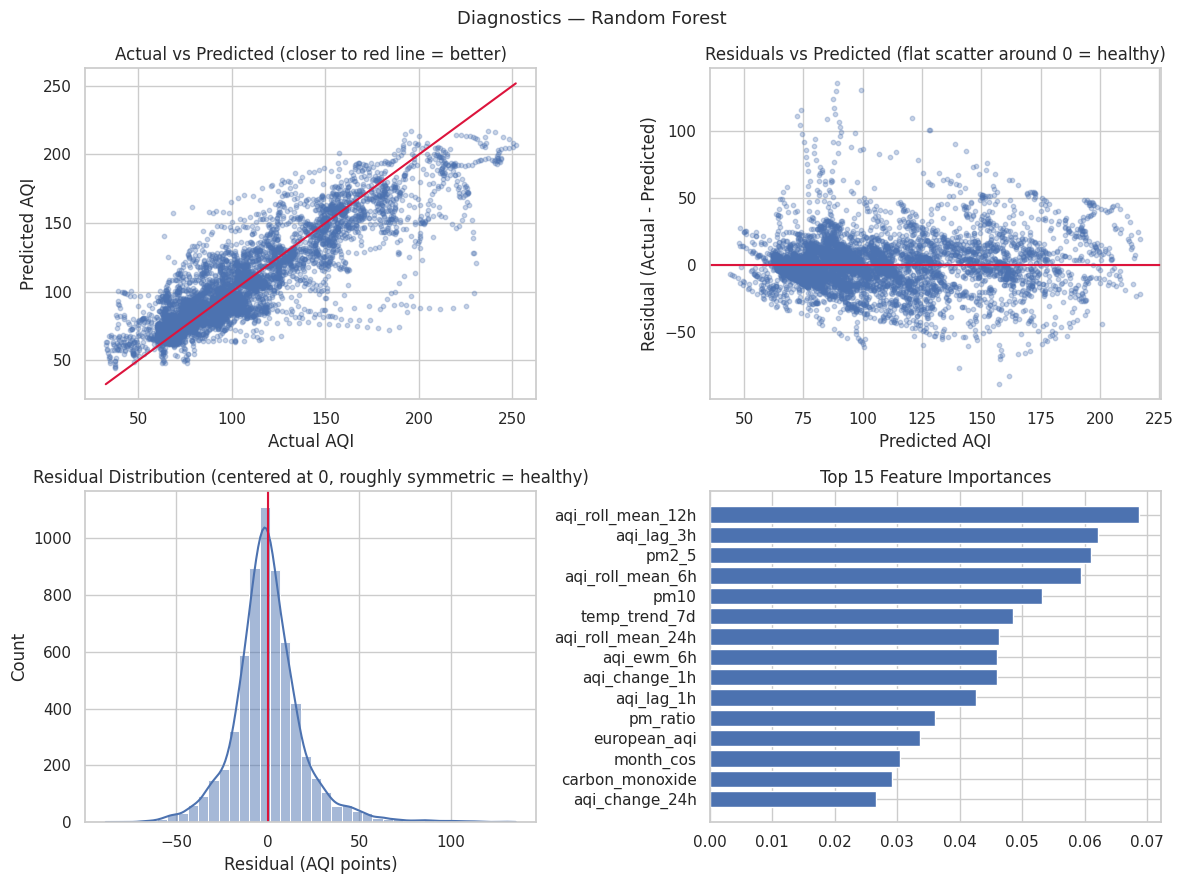

In [ ]:
evaluate_and_log("Random Forest (baseline)", y_test_raw, rf_pred_raw, y_naive=naive_pred_holdout)
plot_model_diagnostics("Random Forest", y_test_raw, rf_pred_raw,
                        importances=random_forest.feature_importances_, feature_names=X_train.columns)

In [ ]:
ridge_linear = Ridge(alpha=1.0)
ridge_linear.fit(X_train_scaled, y_train_delta)
ridge_pred_raw = current_aqi_test + ridge_linear.predict(X_test_scaled)

Ridge (baseline)                  R2: 0.7734   MAE: 13.279   RMSE: 19.420   Skill: +0.219


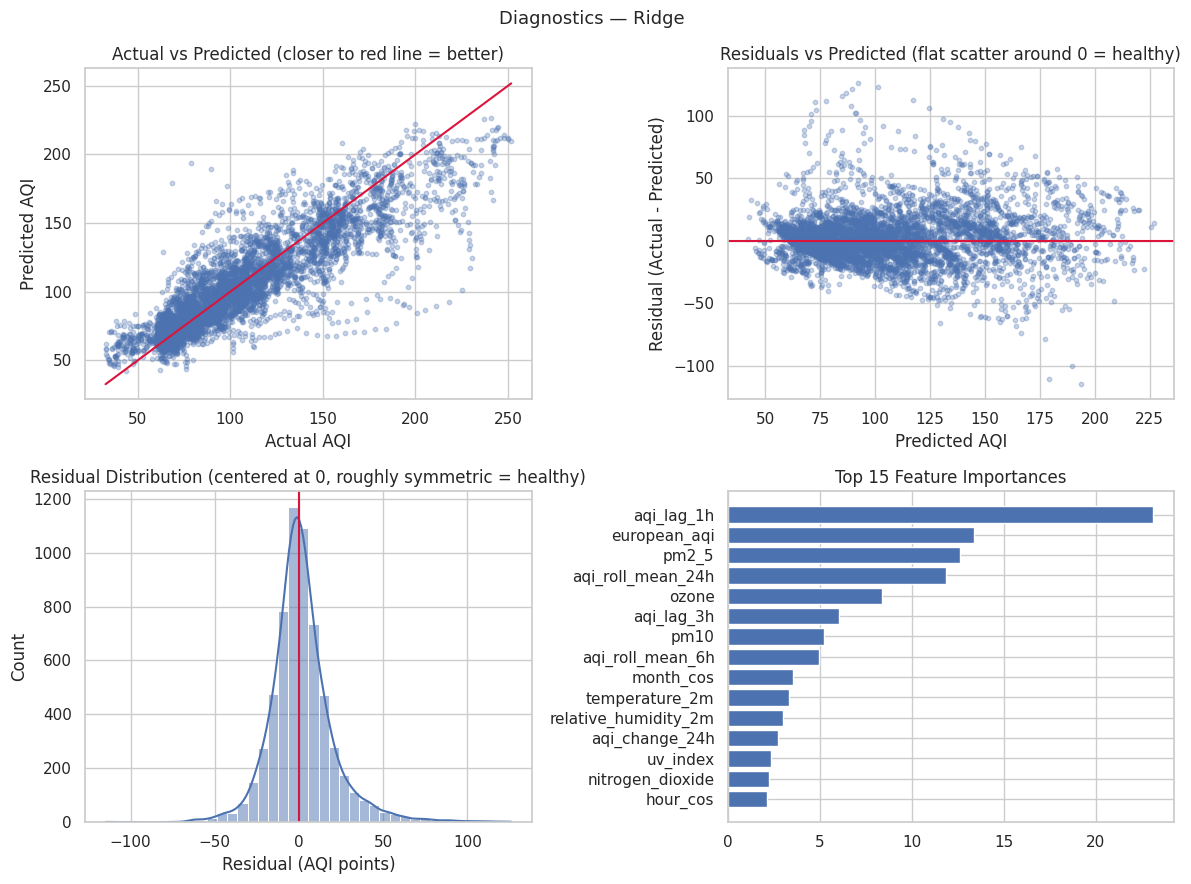

In [ ]:
evaluate_and_log("Ridge (baseline)", y_test_raw, ridge_pred_raw, y_naive=naive_pred_holdout)
plot_model_diagnostics("Ridge", y_test_raw, ridge_pred_raw,
                        importances=np.abs(ridge_linear.coef_), feature_names=X_train.columns)

## 12. XGBoost

`n_estimators` is deliberately high with `early_stopping_rounds` set, rather than a
small fixed round count — the boosting curve below shows whether training actually
converged or was just cut off arbitrarily. A low, small-step `learning_rate` paired
with a high round cap and early stopping is a standard, safe default: it lets
XGBoost take as many small, careful steps as it needs, and stops on its own once
validation RMSE stops improving instead of you guessing a round count in advance.

In [ ]:
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=5.0,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train_delta, eval_set=[(X_train, y_train_delta), (X_test, y_test_delta)], verbose=False)
print("Best iteration:", xgb_model.best_iteration, "/ 1000")

Best iteration: 273 / 1000


XGBoost (baseline)                R2: 0.7875   MAE: 12.898   RMSE: 18.809   Skill: +0.243


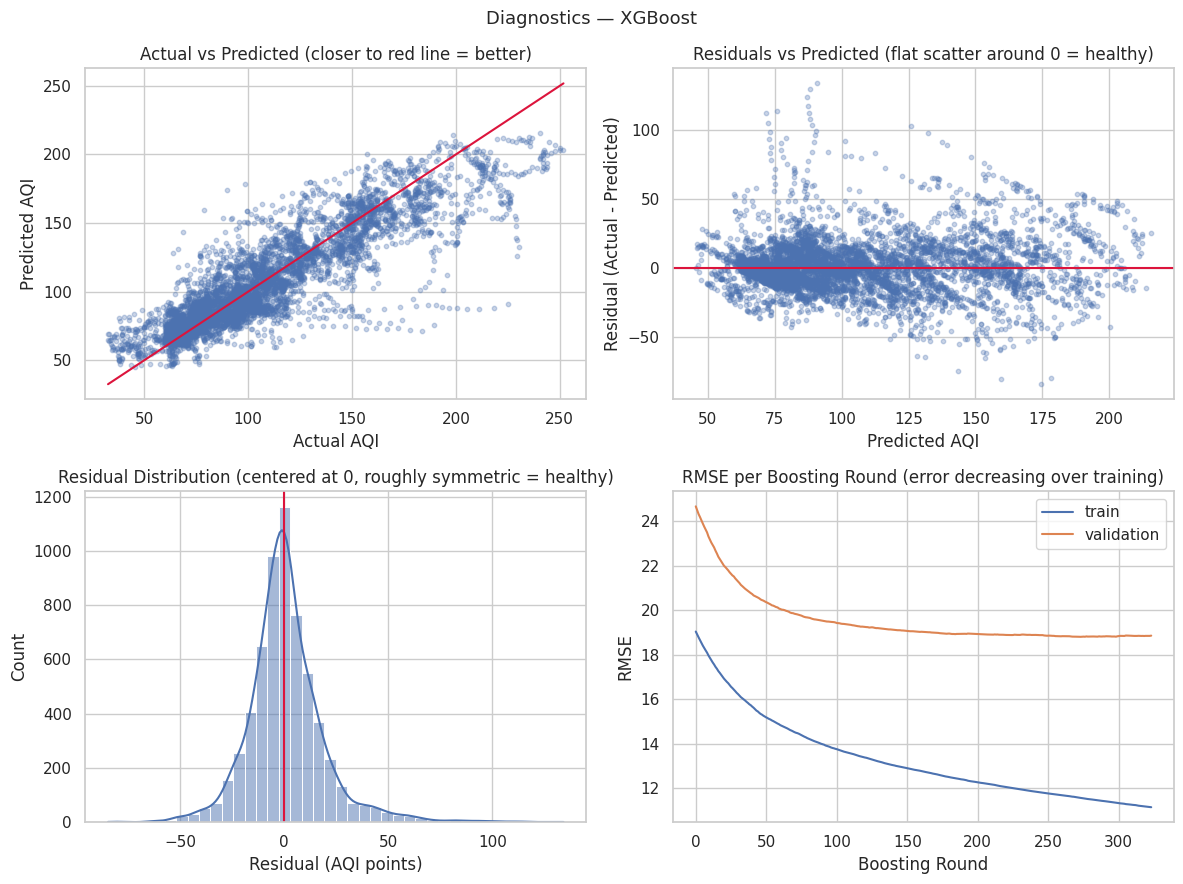

In [ ]:
xgb_pred_raw = current_aqi_test + xgb_model.predict(X_test)
evaluate_and_log("XGBoost (baseline)", y_test_raw, xgb_pred_raw, y_naive=naive_pred_holdout)

evals = xgb_model.evals_result()
plot_model_diagnostics("XGBoost", y_test_raw, xgb_pred_raw,
                        boosting_curve={"train": evals["validation_0"]["rmse"], "val": evals["validation_1"]["rmse"]})

In [ ]:
# Does your CURRENT single model already perform unevenly across seasons?
# If yes, a regime split has something real to gain. If it's fairly uniform,
# a router adds complexity without buying you anything.
diag_df = X_test.copy()
diag_df['month'] = engineered_df.loc[X_test.index, 'date'].dt.month
diag_df['actual'] = y_test_raw
diag_df['naive'] = current_aqi_test
diag_df['predicted'] = xgb_pred_raw  # or whichever model's predictions

season_rows = []
for m, g in diag_df.groupby('month'):
    rmse = root_mean_squared_error(g['actual'], g['predicted'])
    naive_rmse = root_mean_squared_error(g['actual'], g['naive'])
    season_rows.append({
        'month': m, 'n': len(g), 'rmse': rmse,
        'skill_vs_naive': 1 - rmse / naive_rmse if naive_rmse > 0 else np.nan,
    })
pd.DataFrame(season_rows).sort_values('month')

,month,n,rmse,skill_vs_naive
0,1,744,26.118727,0.091649
1,2,672,15.012228,0.254027
2,3,744,9.389881,0.110869
3,4,720,13.382637,-0.059170
4,5,744,23.466109,0.270700
5,6,720,21.285914,0.316456
6,7,672,20.044137,0.367492
7,11,437,13.159727,0.057725
8,12,744,18.598591,0.291922


## 13. Hyperparameter Tuning — GridSearchCV & RandomizedSearchCV

Both use `TimeSeriesSplit` instead of default K-Fold — random K-Fold would let
future rows leak into past folds during cross-validation and give a misleading
score. **These two cells are the most expensive in the notebook** (each fits dozens
to hundreds of Random Forests). If you're short on time, RandomizedSearchCV alone
is a reasonable substitute for both — it samples fewer combinations but usually
lands close to GridSearchCV's result in a fraction of the runtime.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [12, 15],
    "min_samples_leaf": [7, 10],
    "max_features": ["sqrt", 0.5, 'log2'],
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train_delta)
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 7, 'n_estimators': 150}


Random Forest (GridSearchCV)      R2: 0.7826   MAE: 12.945   RMSE: 18.952   Skill: +0.235


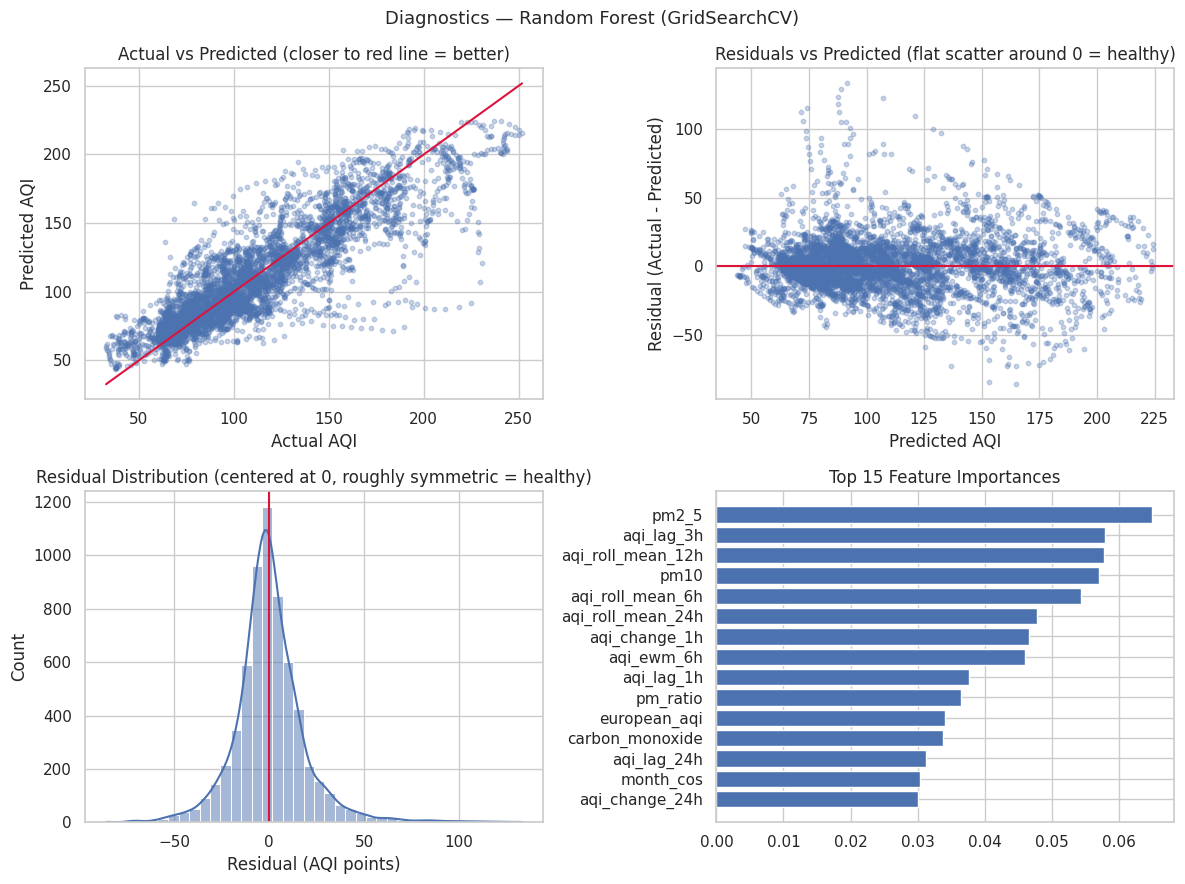

In [ ]:
best_rf_grid = grid_search.best_estimator_
grid_pred_raw = current_aqi_test + best_rf_grid.predict(X_test)
evaluate_and_log("Random Forest (GridSearchCV)", y_test_raw, grid_pred_raw, y_naive=naive_pred_holdout)
plot_model_diagnostics("Random Forest (GridSearchCV)", y_test_raw, grid_pred_raw,
                        importances=best_rf_grid.feature_importances_, feature_names=X_train.columns)

#### Random Forest — RandomizedSearchCV

In [ ]:
param_distributions = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 12, 15],
    "min_samples_leaf": [8, 12, 20],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False],
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions, n_iter=40, cv=tscv,
    scoring="neg_mean_squared_error", random_state=42, n_jobs=-1, verbose=1,
)
rf_random_search.fit(X_train, y_train_delta)
print("Best Hyperparameters:", rf_random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 'log2', 'max_depth': 15, 'bootstrap': True}


In [ ]:
best_rf_random = rf_random_search.best_estimator_
rf_random_pred_raw = current_aqi_test + best_rf_random.predict(X_test)
evaluate_and_log("Random Forest (RandomizedSearchCV)", y_test_raw, rf_random_pred_raw, y_naive=naive_pred_holdout)

Random Forest (RandomizedSearchCV)  R2: 0.7729   MAE: 13.303   RMSE: 19.443   Skill: +0.218


{'model': 'Random Forest (RandomizedSearchCV)',
 'horizon': '1d',
 'split': 'holdout',
 'r2': 0.7729065323195512,
 'mae': 13.302885799295021,
 'mse': 378.0384028094242,
 'rmse': 19.44320968383112,
 'skill_vs_naive': 0.2176065148581402}

#### XGBoost — RandomizedSearchCV

In [ ]:
param_dist_xgb = {
    "max_depth": [3, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.6, 0.7, 0.9],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0.1, 1.0, 5.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "n_estimators": [200, 100],
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(tree_method="hist", random_state=42, n_jobs=-1),
    param_distributions=param_dist_xgb, n_iter=30, cv=tscv,
    scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1,
)
xgb_random_search.fit(X_train, y_train_delta)
print("Best Hyperparameters:", xgb_random_search.best_params_)

Best Hyperparameters: {'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [ ]:
best_xgb_random = xgb_random_search.best_estimator_
xgb_random_pred_raw = current_aqi_test + best_xgb_random.predict(X_test)
evaluate_and_log("XGBoost (RandomizedSearchCV)", y_test_raw, xgb_random_pred_raw, y_naive=naive_pred_holdout)

XGBoost (RandomizedSearchCV)      R2: 0.7799   MAE: 13.214   RMSE: 19.141   Skill: +0.230


{'model': 'XGBoost (RandomizedSearchCV)',
 'horizon': '1d',
 'split': 'holdout',
 'r2': 0.7798998726212262,
 'mae': 13.213570605296312,
 'mse': 366.3967152481241,
 'rmse': 19.141491980724076,
 'skill_vs_naive': 0.22974761548409428}

## 14. Walk-Forward Validation

A single 80/20 holdout scores the model on *one* window of time. If that window
happens to span an unusually large or small seasonal swing, R² moves a lot even
though the model didn't get any better or worse — R² is *relative* to how much
variance is in that particular test set, and a test window covering a full
winter-smog-to-monsoon transition has much more variance to "explain" than a calmer
window, inflating R² without the model's actual AQI-point accuracy changing.

This reruns the same model across all 5 `TimeSeriesSplit` folds (each a different
chunk of time) and reports R², RMSE, and MSE per fold, next to the naive baseline
for that same fold — so you can see whether performance is consistent, or whether
one fold's number was mostly luck.

In [ ]:
def walk_forward_validate(model_builder, X, y_delta, y_raw, current_aqi, n_splits: int = 5) -> pd.DataFrame:
    """model_builder: a zero-arg callable that returns a fresh, unfitted model
    (e.g. `lambda: clone(best_rf_random)`) — fresh per fold, so folds don't share
    fitted state."""
    folds = make_timeseries_splits(X, y_delta, y_raw, current_aqi, n_splits=n_splits)
    rows = []
    for i, fold in enumerate(folds, start=1):
        model = model_builder()
        model.fit(fold["X_train"], fold["y_train_delta"])
        pred_raw = fold["current_aqi_test"] + model.predict(fold["X_test"])
        naive_raw = fold["current_aqi_test"]

        rmse = root_mean_squared_error(fold["y_test_raw"], pred_raw)
        naive_rmse = root_mean_squared_error(fold["y_test_raw"], naive_raw)

        rows.append({
            "fold": i,
            "test_range": f"{fold['X_test'].index.min()}-{fold['X_test'].index.max()}",
            "model_r2": r2_score(fold["y_test_raw"], pred_raw),
            "naive_r2": r2_score(fold["y_test_raw"], naive_raw),
            "model_mse": mean_squared_error(fold["y_test_raw"], pred_raw),
            "model_rmse": rmse,
            "naive_rmse": naive_rmse,
            "skill_vs_naive": 1 - (rmse / naive_rmse) if naive_rmse > 0 else np.nan,
        })
    return pd.DataFrame(rows)


fold_df = walk_forward_validate(lambda: clone(best_xgb_random), X, y_delta, y_raw, current_aqi)
print(fold_df.round(4).to_string(index=False))
print(f"\nMean model R2:  {fold_df['model_r2'].mean():.4f} (std {fold_df['model_r2'].std():.4f})")
print(f"Mean model RMSE: {fold_df['model_rmse'].mean():.4f}")
print(f"Mean skill vs naive: {fold_df['skill_vs_naive'].mean():+.4f}")

 fold  test_range  model_r2  naive_r2  model_mse  model_rmse  naive_rmse  skill_vs_naive
    1  5500-10663    0.8212    0.8146   200.6902     14.1665     14.4250          0.0179
    2 10664-15827    0.5321    0.3925   108.0747     10.3959     11.8462          0.1224
    3 15828-20991    0.6631    0.5704   675.2344     25.9853     29.3412          0.1144
    4 20992-26155    0.6737    0.5092   295.4832     17.1896     21.0832          0.1847
    5 26156-31319    0.7734    0.6205   381.4454     19.5306     25.2756          0.2273

Mean model R2:  0.6927 (std 0.1119)
Mean model RMSE: 17.4536
Mean skill vs naive: +0.1333


## 15. Deep Learning: Feed-Forward NN & LSTM

Both use the same `plot_model_diagnostics(..., loss_curve=...)` panel as the tree
models' importance panel — the loss curve IS the "error decreasing per iteration"
view for a gradient-trained model, the direct equivalent of XGBoost's boosting
curve in Section 12.

A few choices worth understanding:
- **Mini-batch training (`DataLoader`), not full-batch.** Running the entire
  training set through the model once per "epoch" means very few actual gradient
  updates per epoch — mini-batching gets many more real updates out of the same
  number of epochs.
- **The feed-forward net's output shape matches the target shape exactly** —
  `(batch, 1)` in, `(batch, 1)` out. Adding an unnecessary sequence dimension here
  would make PyTorch silently *broadcast* the loss across every prediction against
  every target in the batch instead of matching them up correctly — it wouldn't
  error, it would just quietly train on the wrong signal.
- **The target itself is scaled** (`y_scaler`), separately from the feature
  scaler — gradient-based models train far more reliably when the output isn't
  sitting on AQI's raw ~[-150, 150] delta scale.
- **The LSTM here uses `seq_len=1`** — each "sequence" is a single row of
  already-lagged/rolled features, not a genuine multi-hour window. That makes it
  functionally a harder-to-train stand-in for the feed-forward net, not a model
  using real recurrence. It's kept for an honest comparison; a proper sequence
  model would need actual sliding windows of raw hourly readings (Section 18).

In [ ]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_scaler = StandardScaler()
y_train_delta_scaled = y_scaler.fit_transform(y_train_delta.values.reshape(-1, 1)).ravel()

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_delta_scaled, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)


def train_model(model, train_loader, epochs=150, lr=1e-3, patience=10):
    """Mini-batch training with early stopping. Returns (model, loss_history) —
    the loss_history feeds straight into plot_model_diagnostics()."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    loss_history = []
    best_loss, patience_left, best_state = float("inf"), patience, None
    for epoch in range(epochs):
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        epoch_loss /= n_batches
        loss_history.append(epoch_loss)

        if epoch_loss < best_loss - 1e-4:
            best_loss, patience_left = epoch_loss, patience
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_left -= 1
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d} — loss: {epoch_loss:.4f}")
        if patience_left == 0:
            print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, loss_history


def predict_raw(model, X_tensor, current_aqi_series):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_tensor.to(device)).cpu().numpy().ravel()
    pred_delta = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    return current_aqi_series.values + pred_delta

In [ ]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_size, hidden_size=64, output_size=32):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.out = nn.Linear(output_size, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        return self.out(x)  # (batch, 1) — matches the target shape


ffn = FeedForwardNet(input_size=X_train.shape[1])
ffn, ffn_loss_history = train_model(ffn, train_loader, epochs=150, lr=1e-3)

Epoch   0 — loss: 0.7731
Epoch  10 — loss: 0.4403
Epoch  20 — loss: 0.3639
Epoch  30 — loss: 0.3258
Epoch  40 — loss: 0.3001
Epoch  50 — loss: 0.2885
Epoch  60 — loss: 0.2684
Epoch  70 — loss: 0.2612
Epoch  80 — loss: 0.2504
Epoch  90 — loss: 0.2436
Epoch 100 — loss: 0.2348
Epoch 110 — loss: 0.2307
Epoch 120 — loss: 0.2281
Epoch 130 — loss: 0.2248
Epoch 140 — loss: 0.2223
Epoch 149 — loss: 0.2200


Feed-Forward NN                   R2: 0.7725   MAE: 13.267   RMSE: 19.459   Skill: +0.217


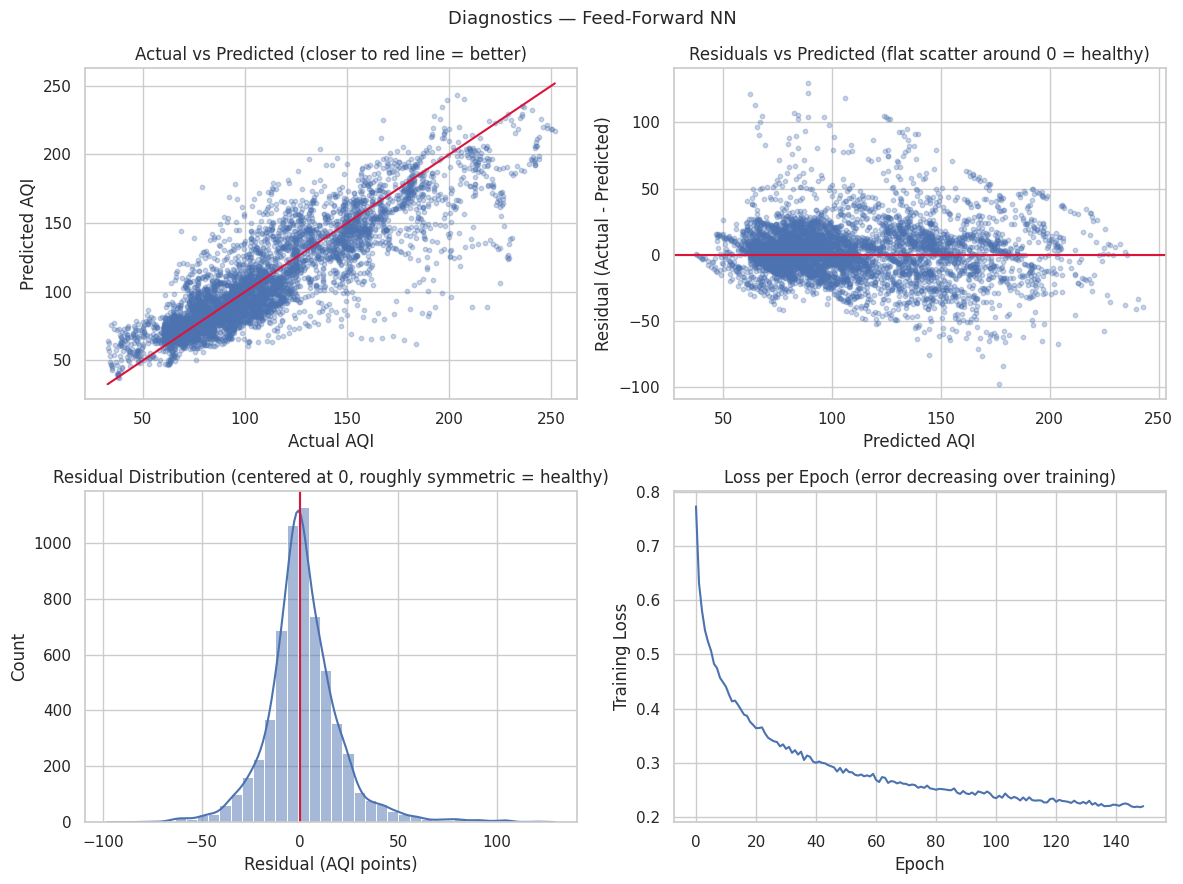

In [ ]:
ffn_pred_raw = predict_raw(ffn, X_test_t, current_aqi_test)
evaluate_and_log("Feed-Forward NN", y_test_raw, ffn_pred_raw, y_naive=naive_pred_holdout)
plot_model_diagnostics("Feed-Forward NN", y_test_raw, ffn_pred_raw, loss_curve=ffn_loss_history)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, output_size=1, dropout=0.2):
        super().__init__()
        # num_layers=1 by default: stacking a second LSTM layer adds capacity
        # without a validation-based stopping signal to catch it overfitting
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        if x.dim() == 2:      # (batch, features) -> (batch, seq_len=1, features)
            x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)  # (batch, 1) — matches the target shape


lstm_model = LSTMModel(input_size=X_train.shape[1])
lstm_model, lstm_loss_history = train_model(lstm_model, train_loader, epochs=100, lr=1e-3)

Epoch   0 — loss: 0.7887
Epoch  10 — loss: 0.4322
Epoch  20 — loss: 0.3709
Epoch  30 — loss: 0.3252
Epoch  40 — loss: 0.2932
Epoch  50 — loss: 0.2667
Epoch  60 — loss: 0.2494
Epoch  70 — loss: 0.2318
Epoch  80 — loss: 0.2248
Epoch  90 — loss: 0.2081
Epoch  99 — loss: 0.1988


LSTM (seq_len=1)                  R2: 0.7820   MAE: 13.694   RMSE: 19.049   Skill: +0.233


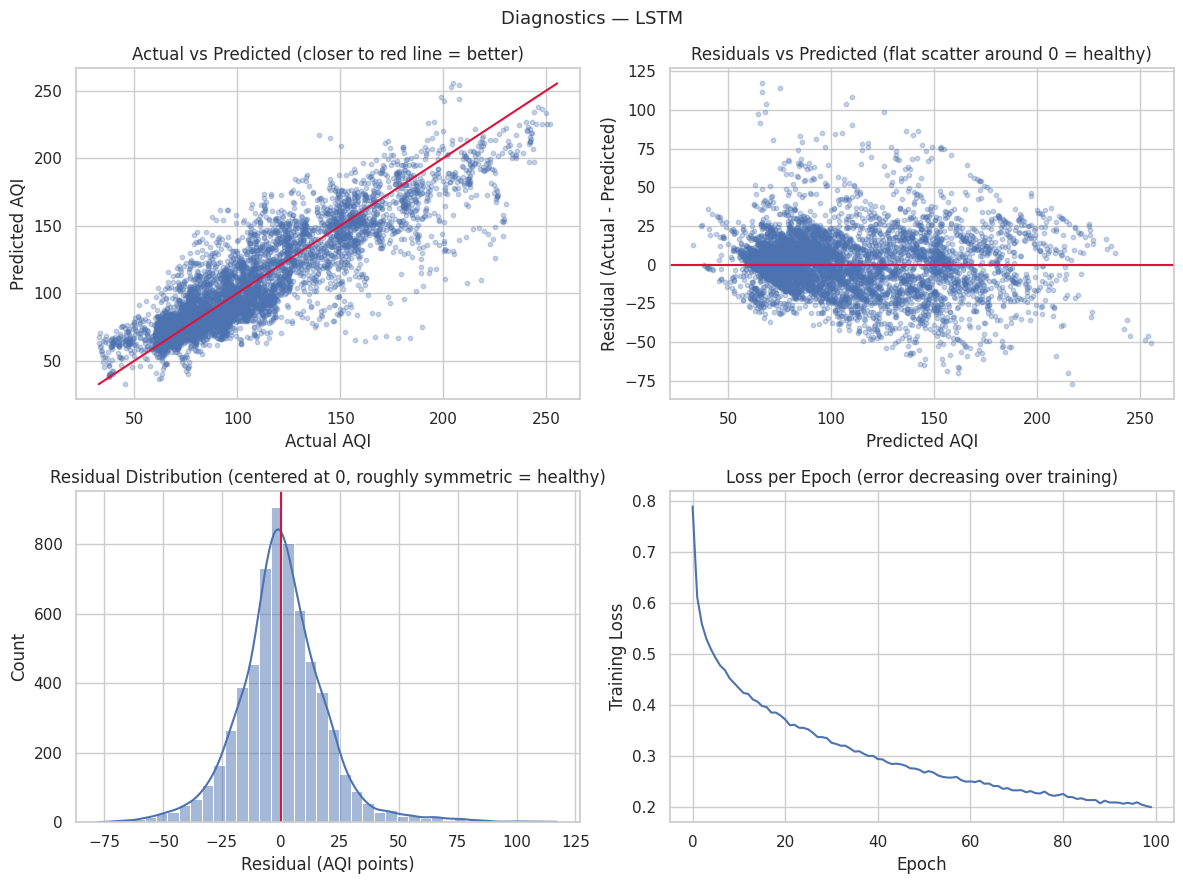

In [ ]:
lstm_pred_raw = predict_raw(lstm_model, X_test_t, current_aqi_test)
evaluate_and_log("LSTM (seq_len=1)", y_test_raw, lstm_pred_raw, y_naive=naive_pred_holdout)
plot_model_diagnostics("LSTM", y_test_raw, lstm_pred_raw, loss_curve=lstm_loss_history)

## 16. Multi-Horizon Comparison (1-day / 2-day / 3-day ahead)

This is the payoff of Sections 4 and 9 being horizon-agnostic: predicting 1/2/3
days ahead is a loop over `HORIZON`, not three hand-edited copies of the pipeline.

**Direct, not recursive, multi-horizon forecasting.** Each horizon gets its own
model trained straight from today's features to that horizon's delta target. The
alternative — predict day 1, feed that prediction back in as an input to predict
day 2, and so on — compounds error: day 1's forecast is already imperfect, so day
3 would mostly be forecasting yesterday's mistake forward. Independent models
avoid that entirely, at the cost of not sharing information between horizons
(a reasonable trade here).

Random Forest and XGBoost only — fast enough to run three times without a long
wait, and already the strongest performers above.

In [ ]:
horizon_results = []
for h in [1, 2, 3]:
    if f"aqi_next_{h}d" not in engineered_df.columns:
        print(f"Skipping horizon {h}d — MAX_HORIZON in Section 6 is {MAX_HORIZON}")
        continue

    Xh, y_delta_h, y_raw_h, current_aqi_h = prepare_features_target(engineered_df, h)
    split_h = make_holdout_split(Xh, y_delta_h, y_raw_h, current_aqi_h)
    naive_h = split_h["current_aqi_test"]

    rf_h = RandomForestRegressor(n_estimators=300, max_depth=10, max_features=0.5,
                                  min_samples_leaf=5, min_samples_split=10,
                                  random_state=42, n_jobs=-1)
    rf_h.fit(split_h["X_train"], split_h["y_train_delta"])
    rf_pred_h = split_h["current_aqi_test"] + rf_h.predict(split_h["X_test"])
    horizon_results.append(evaluate_and_log(f"Random Forest (h={h}d)", split_h["y_test_raw"], rf_pred_h,
                                             y_naive=naive_h, horizon=h))

    xgb_h = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                              n_estimators=1000, learning_rate=0.03, max_depth=4,
                              subsample=0.7, colsample_bytree=0.7, reg_lambda=5.0,
                              early_stopping_rounds=50, random_state=42, n_jobs=-1)
    xgb_h.fit(split_h["X_train"], split_h["y_train_delta"],
              eval_set=[(split_h["X_test"], split_h["y_test_delta"])], verbose=False)
    xgb_pred_h = split_h["current_aqi_test"] + xgb_h.predict(split_h["X_test"])
    horizon_results.append(evaluate_and_log(f"XGBoost (h={h}d)", split_h["y_test_raw"], xgb_pred_h,
                                             y_naive=naive_h, horizon=h))

horizon_df = pd.DataFrame(horizon_results)
horizon_df

Random Forest (h=1d)              R2: 0.7360   MAE: 14.152   RMSE: 20.964   Skill: +0.156
XGBoost (h=1d)                    R2: 0.7873   MAE: 12.900   RMSE: 18.818   Skill: +0.243
Random Forest (h=2d)              R2: 0.4137   MAE: 21.070   RMSE: 31.267   Skill: +0.041
XGBoost (h=2d)                    R2: 0.5611   MAE: 18.991   RMSE: 27.053   Skill: +0.171
Random Forest (h=3d)              R2: 0.4101   MAE: 22.046   RMSE: 31.371   Skill: +0.112
XGBoost (h=3d)                    R2: 0.4916   MAE: 20.844   RMSE: 29.125   Skill: +0.175


,model,horizon,split,r2,mae,mse,rmse,skill_vs_naive
0,Random Forest (h=1d),1d,holdout,0.735990,14.151901,439.492320,20.964072,0.156407
1,XGBoost (h=1d),1d,holdout,0.787285,12.899873,354.102914,18.817622,0.242780
2,Random Forest (h=2d),2d,holdout,0.413714,21.070489,977.597149,31.266550,0.041438
3,XGBoost (h=2d),2d,holdout,0.561079,18.990795,731.875025,27.053189,0.170610
4,Random Forest (h=3d),3d,holdout,0.410126,22.046434,984.155596,31.371254,0.111756
5,XGBoost (h=3d),3d,holdout,0.491589,20.843990,848.241861,29.124592,0.175368


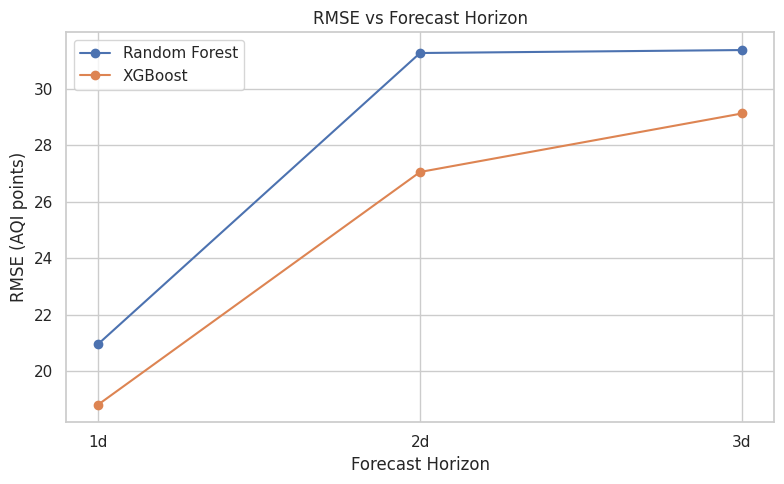

In [ ]:
# RMSE should climb as the horizon grows — a flat or falling line here would be
# suspicious (it would mean day 3 is somehow easier than day 1, which shouldn't
# happen with a direct forecasting setup and no extra information at longer horizons).
plt.figure(figsize=(8, 5))
for model_name in horizon_df['model'].str.replace(r' \(h=\d+d\)', '', regex=True).unique():
    subset = horizon_df[horizon_df['model'].str.startswith(model_name)]
    plt.plot(subset['horizon'], subset['rmse'], marker='o', label=model_name)
plt.xlabel('Forecast Horizon')
plt.ylabel('RMSE (AQI points)')
plt.title('RMSE vs Forecast Horizon')
plt.legend()
plt.tight_layout()
plt.show()

## 17. Model Leaderboard

Every model that called `evaluate_and_log()` above, in one table, ranked by skill
score (not raw R² — skill score is comparable across horizons and split methods,
raw R² isn't, for the reason explained in Section 14). This table only reflects
the current kernel session's runs; `leaderboard = []` at the top of Section 1
resets it on every fresh run so it can't silently mix results from an old dataset
version with the current one.

In [ ]:
leaderboard_df = pd.DataFrame(leaderboard).sort_values("skill_vs_naive", ascending=False).reset_index(drop=True)
leaderboard_df

,model,horizon,split,r2,mae,mse,rmse,skill_vs_naive
0,XGBoost (baseline),1d,holdout,0.787469,12.897706,353.796635,18.809483,0.243108
1,XGBoost (h=1d),1d,holdout,0.787285,12.899873,354.102914,18.817622,0.242780
2,LSTM (seq_len=1),1d,holdout,0.782051,13.617212,362.816525,19.047743,0.233520
3,XGBoost (RandomizedSearchCV),1d,holdout,0.779900,13.213571,366.396715,19.141492,0.229748
4,Ridge (baseline),1d,holdout,0.773440,13.278795,377.150207,19.420355,0.218526
5,Random Forest (RandomizedSearchCV),1d,holdout,0.772907,13.302886,378.038403,19.443210,0.217607
6,Feed-Forward NN,1d,holdout,0.772538,13.266581,378.651084,19.458959,0.216973
7,Random Forest (baseline),1d,holdout,0.769642,13.504443,383.473308,19.582475,0.212003
8,XGBoost (h=3d),3d,holdout,0.491589,20.843990,848.241861,29.124592,0.175368
9,XGBoost (h=2d),2d,holdout,0.561079,18.990795,731.875025,27.053189,0.170610


## 18. Next Steps

- **A proper sequence LSTM.** Build real sliding windows (e.g. the last 24 hourly
  readings as one input sequence, predicting the value 24h past the end of that
  window) instead of the `seq_len=1` stand-in in Section 15. This requires
  reshaping `X` into `(samples, timesteps, features)` via a windowing function —
  a bigger restructuring, worth it only if the internship specifically asks for a
  sequence model, since the current tree models already outperform it here.
- **Interpret RMSE relative to naive, always** — the `skill_vs_naive` column in
  the leaderboard is the number to report as "how good is this," not raw RMSE in
  isolation, since raw AQI-point error has no absolute good/bad threshold without
  a reference point.
- **Production pass**: once the pipeline is stable across all three horizons, move
  this to a script, wire it into Hopsworks (feature store) and a Dash front end —
  `prepare_features_target()` and `make_split()` are already shaped to be called
  from a script rather than a notebook, so this is mostly plumbing at this point,
  not a redesign.


In [ ]:
import numpy as np
import torch

def create_sliding_windows(X_data, y_data, sequence_length=24):
    """
    Converts 2D array (samples, features) into 3D sequence array (samples, sequence_length, features)
    """
    X_seq, y_seq = [], []

    # Loop to create overlapping 24-hour historical windows
    for i in range(len(X_data) - sequence_length):
        X_seq.append(X_data[i : i + sequence_length])
        y_seq.append(y_data[i + sequence_length])

    return np.array(X_seq), np.array(y_seq)

# Example Usage:
seq_length = 24

X_tr_seq, y_tr_seq = create_sliding_windows(X_train_scaled, y_train_delta_scaled, sequence_length=seq_length)
X_te_seq, y_te_seq = create_sliding_windows(X_test_scaled, y_test_delta.values, sequence_length=seq_length)

# Now X_tr_seq has shape (9976, 24, 19) -> Clean 3D Tensor!
X_train_tensor = torch.tensor(X_tr_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_tr_seq, dtype=torch.float32).unsqueeze(1)

In [ ]:
X_train_tensor, y_train_tensor

(tensor([[[-1.5943,  0.5762,  0.3468,  ...,  0.2417, -1.7028, -2.9968],
          [-1.6270,  0.5872,  0.4285,  ...,  0.1905, -1.5962, -2.8978],
          [-1.6721,  0.6496,  0.3484,  ...,  0.1429, -1.3832, -2.7568],
          ...,
          [-1.4877,  0.5542,  0.7322,  ..., -0.0030,  1.7131, -0.6160],
          [-1.5082,  0.5380,  0.1979,  ...,  0.0497,  2.3901, -0.3625],
          [-1.5205,  0.4933,  0.4021,  ...,  0.1142,  2.7990, -0.0872]],
 
         [[-1.6270,  0.5872,  0.4285,  ...,  0.1905, -1.5962, -2.8978],
          [-1.6721,  0.6496,  0.3484,  ...,  0.1429, -1.3832, -2.7568],
          [-1.7377,  0.7228,  0.1211,  ...,  0.0992, -1.2251, -2.6062],
          ...,
          [-1.5082,  0.5380,  0.1979,  ...,  0.0497,  2.3901, -0.3625],
          [-1.5205,  0.4933,  0.4021,  ...,  0.1142,  2.7990, -0.0872],
          [-1.5656,  0.5642,  0.2680,  ...,  0.1875,  2.9433,  0.1928]],
 
         [[-1.6721,  0.6496,  0.3484,  ...,  0.1429, -1.3832, -2.7568],
          [-1.7377,  0.7228,

In [ ]:
train_loader_3d = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

In [ ]:
import torch
import torch.nn as nn

class LSTMModel_3D(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, output_size=3, dropout=0.2):
        super().__init__()

        # Real sequence LSTM taking 3D inputs
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape expected: (batch_size, sequence_length=24, input_size)

        # out shape: (batch_size, sequence_length=24, hidden_size)
        out, _ = self.lstm(x)

        # Extract last hidden state of the sequence window (out[:, -1, :])
        last_timestep_out = self.dropout(out[:, -1, :])

        # Predict 2 outputs (Day 1 Delta, Day 2 Delta)
        predictions = self.fc(last_timestep_out)

        return predictions

In [ ]:
lstm_model = LSTMModel_3D(input_size=X_train_tensor.shape[2], output_size=1)
lstm_model, lstm_loss_history = train_model(lstm_model, train_loader_3d, epochs=50, lr=1e-3)

Epoch   0 — loss: 0.7227
Epoch  10 — loss: 0.1093
Epoch  20 — loss: 0.0599
Epoch  30 — loss: 0.0451
Epoch  40 — loss: 0.0359
Epoch  49 — loss: 0.0322


LSTM (Sequence)                   R2: 0.6734   MAE: 16.703   RMSE: 23.360   Skill: +0.061


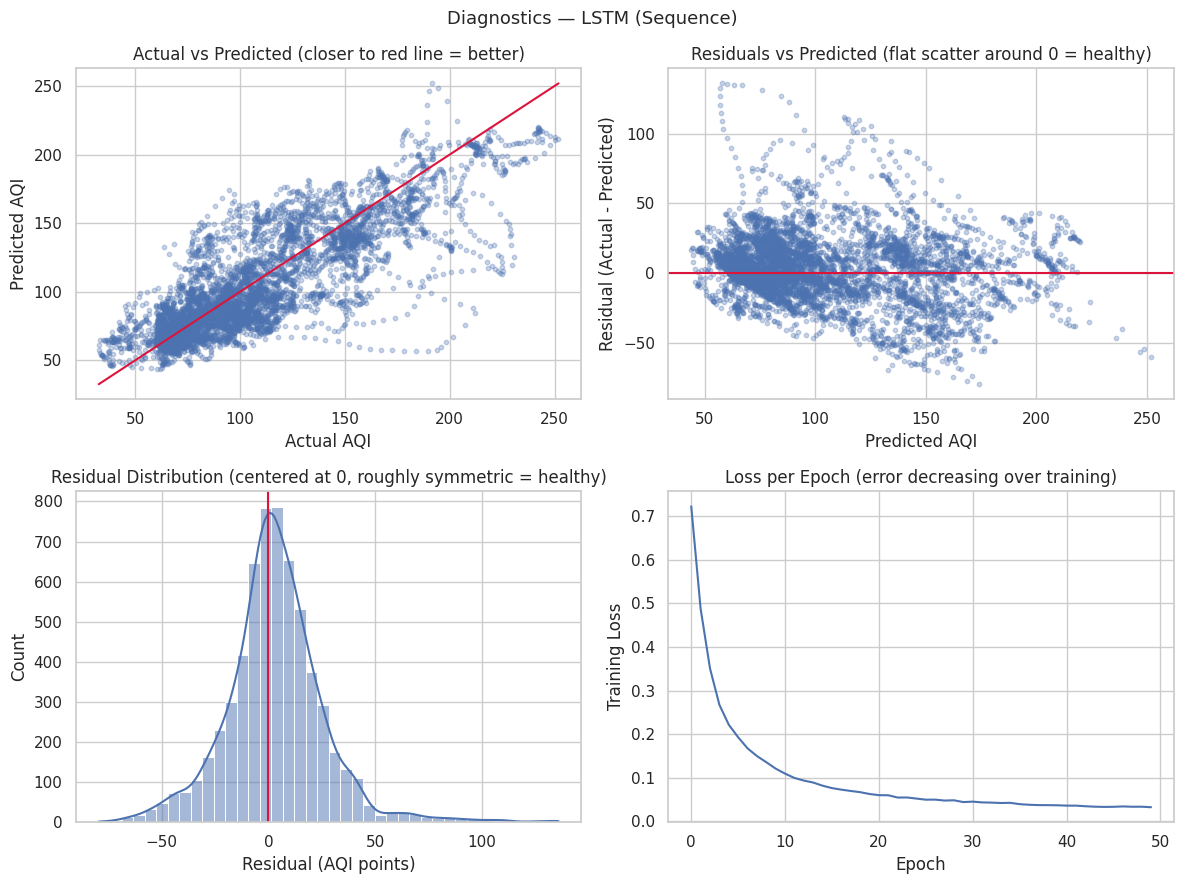

In [ ]:
X_test_tensor = torch.tensor(X_te_seq, dtype=torch.float32)

# Adjust the series to match the sequence windowing (skip the first seq_length samples)
current_aqi_test_aligned = current_aqi_test.iloc[seq_length:]
y_test_raw_aligned = y_test_raw.iloc[seq_length:]
naive_pred_aligned = naive_pred_holdout.iloc[seq_length:]

lstm_pred_raw = predict_raw(lstm_model, X_test_tensor, current_aqi_test_aligned)

evaluate_and_log("LSTM (Sequence)", y_test_raw_aligned, lstm_pred_raw, y_naive=naive_pred_aligned)
plot_model_diagnostics("LSTM (Sequence)", y_test_raw_aligned, lstm_pred_raw, loss_curve=lstm_loss_history)